<a href="https://colab.research.google.com/github/kwanda2426/projects/blob/main/geospatial/Hw_2/Homework2_Practical1_Geodata_Tools.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style="color:green">Kwanda Mazibuko - stdnr: 1077167
</span>

# <span style="color:blue">Practical 1: Geospatial Visualization
</span>

In [ ]:
!pip install contextily
!geopandas

/bin/bash: line 1: geopandas: command not found


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx


#ignoring warnings
import warnings
warnings.filterwarnings('ignore')

#making sure that we can see all rows and cols
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

In [ ]:
# Loading Data
url = "https://raw.githubusercontent.com/kwanda2426/projects/main/geospatial/Hw_2/Imputed_merged_chem.csv"
df = pd.read_csv(url)
df.head()

,Unnamed: 0.1,Unnamed: 0,Unique ID,NTS Sheet,Latitude_NAD83,Longitude_NAD83,Old Zn,Old Cu,Old Pb,Old Ni,Old Co,Old Ag,Old Mn,Old Fe,Old As,Old Mo,Old F,LOI,Old Hg,Old U,Sample Type,NTS,Latitude (NAD 27),Longitude (NAD 27),New Ag,New Al,New As,New Au,New B,New Ba,New Be,New Bi,New Ca,New Cd,New Ce,New Co,New Cr,New Cs,New Cu,New Dy,New Er,New Eu,New Fe,New Ga,New Gd,New Ge,New Hf,New Hg,New Ho,New In,New K,New La,New Li,New Lu,New Mg,New Mn,New Mo,New Na,New Nb,New Nd,New Ni,New P,New Pb,New Pd,New Pr,New Pt,New Rb,New Re,New S,New Sb,New Sc,New Se,New Sm,New Sn,New Sr,New Ta,New Tb,New Te,New Th,New Ti,New Tl,New Tm,New U,New V,New W,New Y,New Yb,New Zn,New Zr,Imputed Old Zn,Imputed Old Cu,Imputed Old Ni,Imputed Old Co,Imputed Old Mn,Imputed Old Fe,Imputed Old F,Imputed Old Hg,Imputed Old U,Imputed New Ag,Imputed New Al,Imputed New Ba,Imputed New Be,Imputed New Ca,Imputed New Cd,Imputed New Ce,Imputed New Co,Imputed New Cr,Imputed New Cs,Imputed New Cu,Imputed New Dy,Imputed New Er,Imputed New Eu,Imputed New Fe,Imputed New Ga,Imputed New Gd,Imputed New Hg,Imputed New Ho,Imputed New K,Imputed New La,Imputed New Li,Imputed New Lu,Imputed New Mg,Imputed New Mn,Imputed New Mo,Imputed New Na,Imputed New Nb,Imputed New Nd,Imputed New Ni,Imputed New P,Imputed New Pb,Imputed New Pr,Imputed New Rb,Imputed New S,Imputed New Sc,Imputed New Se,Imputed New Sm,Imputed New Sr,Imputed New Tb,Imputed New Th,Imputed New Ti,Imputed New Tl,Imputed New Tm,Imputed New U,Imputed New V,Imputed New Y,Imputed New Yb,Imputed New Zn,Imputed New Zr,geometry
0,0,1,013L781002,013L,54.989093,-62.019071,40.0,38.0,NaN,43.0,10.0,NaN,70.0,1.00,NaN,2.0,85.0,23.0,40.0,0.3,Routine,013L,54.98900,-62.01995,57.0,2.89,NaN,1.0,NaN,81.5,0.2,0.02,0.48,0.32,19.1,9.9,22.6,0.17,43.46,1.18,0.65,0.56,1.06,4.6,1.66,NaN,0.03,46.0,0.23,NaN,0.03,10.5,2.9,0.10,0.26,60.0,0.55,0.103,0.39,11.20,52.9,0.042,1.90,NaN,2.84,NaN,1.6,NaN,0.25,NaN,2.3,0.7,1.90,0.1,41.0,NaN,0.20,NaN,0.8,0.021,0.03,0.10,0.3,31.0,NaN,6.04,0.64,44.0,0.9,40.0,38.0,43.0,10.0,70.0,1.00,85.0,40.0,0.3,57.0,2.89,81.5,0.200000,0.48,0.32,19.1,9.9,22.6,0.17,43.46,1.18,0.65,0.56,1.06,4.6,1.66,46.0,0.23,0.03,10.5,2.9,0.10,0.26,60.0,0.55,0.103,0.39,11.20,52.9,0.042,1.90,2.84,1.6,0.25,2.3,0.7,1.90,41.0,0.20,0.8,0.021,0.03,0.10,0.3,31.0,6.04,0.64,44.0,0.9,POINT (-62.0190714 54.9890932)
1,1,2,013L781003,013L,54.975382,-62.030577,40.0,44.0,NaN,35.0,8.0,NaN,80.0,1.90,NaN,NaN,80.0,33.0,70.0,0.5,Routine,013L,54.97529,-62.03145,106.0,3.22,0.1,1.6,NaN,26.0,NaN,0.02,0.48,0.35,17.9,8.8,20.8,0.18,49.32,1.30,0.53,0.57,2.19,5.0,1.41,NaN,0.03,66.0,0.20,NaN,0.02,10.0,2.5,0.07,0.20,69.0,0.71,0.080,0.55,9.85,44.7,0.094,2.26,NaN,2.61,NaN,1.6,NaN,0.30,0.02,2.3,1.3,1.76,0.1,31.3,NaN,0.19,NaN,0.8,0.021,0.03,0.08,0.3,45.0,NaN,5.65,0.49,45.1,1.0,40.0,44.0,35.0,8.0,80.0,1.90,80.0,70.0,0.5,106.0,3.22,26.0,0.180762,0.48,0.35,17.9,8.8,20.8,0.18,49.32,1.30,0.53,0.57,2.19,5.0,1.41,66.0,0.20,0.02,10.0,2.5,0.07,0.20,69.0,0.71,0.080,0.55,9.85,44.7,0.094,2.26,2.61,1.6,0.30,2.3,1.3,1.76,31.3,0.19,0.8,0.021,0.03,0.08,0.3,45.0,5.65,0.49,45.1,1.0,POINT (-62.0305772 54.9753817)
2,2,3,013L781004,013L,54.976331,-62.044913,46.0,30.0,NaN,34.0,8.0,NaN,80.0,0.70,NaN,2.0,90.0,27.2,50.0,0.6,Routine,013L,54.97623,-62.04579,59.0,2.34,0.1,1.1,NaN,49.9,0.1,0.03,0.56,0.29,20.5,8.3,18.3,0.18,33.34,1.42,0.71,0.66,0.75,4.4,1.77,NaN,0.03,51.0,0.28,NaN,0.02,12.3,3.1,0.09,0.26,58.0,0.46,0.107,0.51,12.79,42.4,0.052,2.15,NaN,3.22,NaN,1.7,NaN,0.27,0.04,2.2,0.7,2.20,0.1,40.9,NaN,0.22,NaN,0.7,0.023,0.04,0.09,0.3,17.0,NaN,7.19,0.64,51.4,0.8,46.0,30.0,34.0,8.0,80.0,0.70,90.0,50.0,0.6,59.0,2.34,49.9,0.100000,0.56,0.29,20.5,8.3,18.3,0.18,33.34,1.42,0.71,0.66,0.75,4.4,1.77,51.0,0.28,0.02,12.3,3.1,0.09,0.26,58.0,0.46,0.107,0.51,12.79,42.4,0.052,2.15,3.22,1.7,0.27,2.2,0.7,2.20,40.9,0.22,0.7,0.023,0.04,0.09,0.3,17.0,7.19,0.64,51.4,0.8,POINT (-62.0449127 54.9763308)
3,3,4,013L781005,013L,54.973541,-62.054790,50.0,26.0,NaN,22.0,6.0,NaN,120.0,0.85,NaN,2.0,60.0,29.6,40.0,0.6,First Field Duplicate,0

In [ ]:
# formatting column names
df.columns = df.columns.str.replace(' ', '_', regex=False)
df.columns = df.columns.str.replace('New', 'NEW', regex=False)
df.columns = df.columns.str.replace('Old', 'OLD', regex=False)
df.columns

Index(['Unnamed:_0.1', 'Unnamed:_0', 'Unique_ID', 'NTS_Sheet',
       'Latitude_NAD83', 'Longitude_NAD83', 'OLD_Zn', 'OLD_Cu', 'OLD_Pb',
       'OLD_Ni',
       ...
       'Imputed_NEW_Ti', 'Imputed_NEW_Tl', 'Imputed_NEW_Tm', 'Imputed_NEW_U',
       'Imputed_NEW_V', 'Imputed_NEW_Y', 'Imputed_NEW_Yb', 'Imputed_NEW_Zn',
       'Imputed_NEW_Zr', 'geometry'],
      dtype='object', length=149)

In [ ]:
#old cols
old_cols = [i for i in df.columns if 'OLD' in i and 'ted' not in i]

#New cols
new_cols = [i for i in df.columns if 'NEW' in i and 'ted' not in i]

# elements in both old and new
pairs = []
new_elements = [j.split('_')[1] for j in new_cols]
print('These are the overlapping elements')
for i in old_cols:
  old_element = i.split('_')[1]
  if old_element in new_elements:
    pair = ['OLD_'+old_element,'NEW_'+old_element]
    print(old_element)
    pairs.append(pair)
print('There are {} pairs of elements'.format(len(pairs)))

These are the overlapping elements
Zn
Cu
Pb
Ni
Co
Ag
Mn
Fe
As
Mo
Hg
U
There are 12 pairs of elements


In [ ]:
# Double-check each name appears in df.columns: if not, an error will be raised
for old_col, new_col in pairs:
    assert old_col in df.columns and new_col in df.columns, f"Missing: {old_col} or {new_col}"

In [ ]:
#final dataframe
df_final = df.copy()
for old_col, new_col in pairs:

    elem = old_col.replace("OLD_", "")

    diff_name = f"{elem}_diff"

    df_final[diff_name] = df_final[new_col] - df_final[old_col]
df_final.head()

,Unnamed:_0.1,Unnamed:_0,Unique_ID,NTS_Sheet,Latitude_NAD83,Longitude_NAD83,OLD_Zn,OLD_Cu,OLD_Pb,OLD_Ni,OLD_Co,OLD_Ag,OLD_Mn,OLD_Fe,OLD_As,OLD_Mo,OLD_F,LOI,OLD_Hg,OLD_U,Sample_Type,NTS,Latitude_(NAD_27),Longitude_(NAD_27),NEW_Ag,NEW_Al,NEW_As,NEW_Au,NEW_B,NEW_Ba,NEW_Be,NEW_Bi,NEW_Ca,NEW_Cd,NEW_Ce,NEW_Co,NEW_Cr,NEW_Cs,NEW_Cu,NEW_Dy,NEW_Er,NEW_Eu,NEW_Fe,NEW_Ga,NEW_Gd,NEW_Ge,NEW_Hf,NEW_Hg,NEW_Ho,NEW_In,NEW_K,NEW_La,NEW_Li,NEW_Lu,NEW_Mg,NEW_Mn,NEW_Mo,NEW_Na,NEW_Nb,NEW_Nd,NEW_Ni,NEW_P,NEW_Pb,NEW_Pd,NEW_Pr,NEW_Pt,NEW_Rb,NEW_Re,NEW_S,NEW_Sb,NEW_Sc,NEW_Se,NEW_Sm,NEW_Sn,NEW_Sr,NEW_Ta,NEW_Tb,NEW_Te,NEW_Th,NEW_Ti,NEW_Tl,NEW_Tm,NEW_U,NEW_V,NEW_W,NEW_Y,NEW_Yb,NEW_Zn,NEW_Zr,Imputed_OLD_Zn,Imputed_OLD_Cu,Imputed_OLD_Ni,Imputed_OLD_Co,Imputed_OLD_Mn,Imputed_OLD_Fe,Imputed_OLD_F,Imputed_OLD_Hg,Imputed_OLD_U,Imputed_NEW_Ag,Imputed_NEW_Al,Imputed_NEW_Ba,Imputed_NEW_Be,Imputed_NEW_Ca,Imputed_NEW_Cd,Imputed_NEW_Ce,Imputed_NEW_Co,Imputed_NEW_Cr,Imputed_NEW_Cs,Imputed_NEW_Cu,Imputed_NEW_Dy,Imputed_NEW_Er,Imputed_NEW_Eu,Imputed_NEW_Fe,Imputed_NEW_Ga,Imputed_NEW_Gd,Imputed_NEW_Hg,Imputed_NEW_Ho,Imputed_NEW_K,Imputed_NEW_La,Imputed_NEW_Li,Imputed_NEW_Lu,Imputed_NEW_Mg,Imputed_NEW_Mn,Imputed_NEW_Mo,Imputed_NEW_Na,Imputed_NEW_Nb,Imputed_NEW_Nd,Imputed_NEW_Ni,Imputed_NEW_P,Imputed_NEW_Pb,Imputed_NEW_Pr,Imputed_NEW_Rb,Imputed_NEW_S,Imputed_NEW_Sc,Imputed_NEW_Se,Imputed_NEW_Sm,Imputed_NEW_Sr,Imputed_NEW_Tb,Imputed_NEW_Th,Imputed_NEW_Ti,Imputed_NEW_Tl,Imputed_NEW_Tm,Imputed_NEW_U,Imputed_NEW_V,Imputed_NEW_Y,Imputed_NEW_Yb,Imputed_NEW_Zn,Imputed_NEW_Zr,geometry,Zn_diff,Cu_diff,Pb_diff,Ni_diff,Co_diff,Ag_diff,Mn_diff,Fe_diff,As_diff,Mo_diff,Hg_diff,U_diff
0,0,1,013L781002,013L,54.989093,-62.019071,40.0,38.0,NaN,43.0,10.0,NaN,70.0,1.00,NaN,2.0,85.0,23.0,40.0,0.3,Routine,013L,54.98900,-62.01995,57.0,2.89,NaN,1.0,NaN,81.5,0.2,0.02,0.48,0.32,19.1,9.9,22.6,0.17,43.46,1.18,0.65,0.56,1.06,4.6,1.66,NaN,0.03,46.0,0.23,NaN,0.03,10.5,2.9,0.10,0.26,60.0,0.55,0.103,0.39,11.20,52.9,0.042,1.90,NaN,2.84,NaN,1.6,NaN,0.25,NaN,2.3,0.7,1.90,0.1,41.0,NaN,0.20,NaN,0.8,0.021,0.03,0.10,0.3,31.0,NaN,6.04,0.64,44.0,0.9,40.0,38.0,43.0,10.0,70.0,1.00,85.0,40.0,0.3,57.0,2.89,81.5,0.200000,0.48,0.32,19.1,9.9,22.6,0.17,43.46,1.18,0.65,0.56,1.06,4.6,1.66,46.0,0.23,0.03,10.5,2.9,0.10,0.26,60.0,0.55,0.103,0.39,11.20,52.9,0.042,1.90,2.84,1.6,0.25,2.3,0.7,1.90,41.0,0.20,0.8,0.021,0.03,0.10,0.3,31.0,6.04,0.64,44.0,0.9,POINT (-62.0190714 54.9890932),4.0,5.46,NaN,9.9,-0.1,NaN,-10.0,0.06,NaN,-1.45,6.0,0.0
1,1,2,013L781003,013L,54.975382,-62.030577,40.0,44.0,NaN,35.0,8.0,NaN,80.0,1.90,NaN,NaN,80.0,33.0,70.0,0.5,Routine,013L,54.97529,-62.03145,106.0,3.22,0.1,1.6,NaN,26.0,NaN,0.02,0.48,0.35,17.9,8.8,20.8,0.18,49.32,1.30,0.53,0.57,2.19,5.0,1.41,NaN,0.03,66.0,0.20,NaN,0.02,10.0,2.5,0.07,0.20,69.0,0.71,0.080,0.55,9.85,44.7,0.094,2.26,NaN,2.61,NaN,1.6,NaN,0.30,0.02,2.3,1.3,1.76,0.1,31.3,NaN,0.19,NaN,0.8,0.021,0.03,0.08,0.3,45.0,NaN,5.65,0.49,45.1,1.0,40.0,44.0,35.0,8.0,80.0,1.90,80.0,70.0,0.5,106.0,3.22,26.0,0.180762,0.48,0.35,17.9,8.8,20.8,0.18,49.32,1.30,0.53,0.57,2.19,5.0,1.41,66.0,0.20,0.02,10.0,2.5,0.07,0.20,69.0,0.71,0.080,0.55,9.85,44.7,0.094,2.26,2.61,1.6,0.30,2.3,1.3,1.76,31.3,0.19,0.8,0.021,0.03,0.08,0.3,45.0,5.65,0.49,45.1,1.0,POINT (-62.0305772 54.9753817),5.1,5.32,NaN,9.7,0.8,NaN,-11.0,0.29,NaN,NaN,-4.0,-0.2
2,2,3,013L781004,013L,54.976331,-62.044913,46.0,30.0,NaN,34.0,8.0,NaN,80.0,0.70,NaN,2.0,90.0,27.2,50.0,0.6,Routine,013L,54.97623,-62.04579,59.0,2.34,0.1,1.1,NaN,49.9,0.1,0.03,0.56,0.29,20.5,8.3,18.3,0.18,33.34,1.42,0.71,0.66,0.75,4.4,1.77,NaN,0.03,51.0,0.28,NaN,0.02,12.3,3.1,0.09,0.26,58.0,0.46,0.107,0.51,12.79,42.4,0.052,2.15,NaN,3.22,NaN,1.7,NaN,0.27,0.04,2.2,0.7,2.20,0.1,40.9,NaN,0.22,NaN,0.7,0.023,0.04,0.09,0.3,17.0,NaN,7.19,0.64,51.4,0.8,46.0,30.0,34.0,8.0,80.0,0.70,90.0,50.0,0.6,59.0,2.34,49.9,0.100000,0.56,0.29,20.5,8.3,18.3,0.18,33.34,1.42,0.71,0.66,0.75,4.4,1.77,51.0,0.28,0.02,12.3,3.1,0.09,0.26,58.0,0.46,0.107,0.51,12.79,42.4,0.052,2.15,3.22,1.7,0.27,2.2,0.7,2.20,40.9,0.22,0.7,0.

In [ ]:
# Difference Summary
diff_cols = [i for i in df_final.columns if 'diff' in i]
df_final[diff_cols].describe()

,Zn_diff,Cu_diff,Pb_diff,Ni_diff,Co_diff,Ag_diff,Mn_diff,Fe_diff,As_diff,Mo_diff,Hg_diff,U_diff
count,3440.000000,3440.000000,2143.000000,3437.000000,3415.000000,606.000000,3406.000000,3440.000000,785.000000,2496.000000,3440.000000,3429.000000
mean,2.908110,1.768686,2.381148,5.355804,0.661523,388.764851,29.451850,-0.027770,3.232739,0.804812,18.234302,-0.069758
std,23.045655,4.956101,2.366633,4.815372,2.243503,275.392603,220.678132,0.468787,4.217697,2.485022,27.621561,1.070556
min,-602.600000,-35.670000,-2.030000,-18.400000,-26.600000,18.800000,-4725.000000,-5.270000,-6.400000,-26.380000,-92.000000,-24.900000
25%,-2.100000,-0.020000,1.305000,2.800000,-0.200000,192.800000,-8.000000,-0.130000,0.500000,-0.280000,1.000000,-0.400000
50%,3.100000,1.375000,2.220000,4.200000,0.400000,332.750000,4.000000,-0.050000,2.000000,0.400000,12.000000,-0.100000
75%,8.500000,3.140000,3.205000,6.400000,1.100000,516.400000,19.000000,0.060000,4.500000,1.300000,28.000000,0.100000
max,704.200000,197.670000,82.240000,94.200000,34.800000,2157.200000,4268.000000,6.800000,29.800000,31.220000,315.000000,30.500000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3441 entries, 0 to 3440
Columns: 149 entries, Unnamed:_0.1 to geometry
dtypes: float64(142), int64(2), object(5)
memory usage: 3.9+ MB


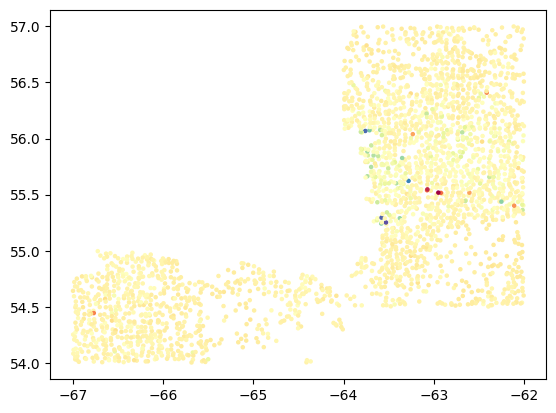

In [ ]:
# We could visualize the spatial data like this - same as any other scatter plot
plt.scatter(df_final['Longitude_NAD83'], df_final['Latitude_NAD83'], s = 5, c = df_final['Mo_diff'], cmap = 'Spectral')

In [ ]:
# First we have to make a geodataframe from a dataframe
gdf = gpd.GeoDataFrame(df_final, geometry = gpd.points_from_xy(df_final['Longitude_NAD83'], df_final['Latitude_NAD83']))
gdf.head()

,Unnamed:_0.1,Unnamed:_0,Unique_ID,NTS_Sheet,Latitude_NAD83,Longitude_NAD83,OLD_Zn,OLD_Cu,OLD_Pb,OLD_Ni,OLD_Co,OLD_Ag,OLD_Mn,OLD_Fe,OLD_As,OLD_Mo,OLD_F,LOI,OLD_Hg,OLD_U,Sample_Type,NTS,Latitude_(NAD_27),Longitude_(NAD_27),NEW_Ag,NEW_Al,NEW_As,NEW_Au,NEW_B,NEW_Ba,NEW_Be,NEW_Bi,NEW_Ca,NEW_Cd,NEW_Ce,NEW_Co,NEW_Cr,NEW_Cs,NEW_Cu,NEW_Dy,NEW_Er,NEW_Eu,NEW_Fe,NEW_Ga,NEW_Gd,NEW_Ge,NEW_Hf,NEW_Hg,NEW_Ho,NEW_In,NEW_K,NEW_La,NEW_Li,NEW_Lu,NEW_Mg,NEW_Mn,NEW_Mo,NEW_Na,NEW_Nb,NEW_Nd,NEW_Ni,NEW_P,NEW_Pb,NEW_Pd,NEW_Pr,NEW_Pt,NEW_Rb,NEW_Re,NEW_S,NEW_Sb,NEW_Sc,NEW_Se,NEW_Sm,NEW_Sn,NEW_Sr,NEW_Ta,NEW_Tb,NEW_Te,NEW_Th,NEW_Ti,NEW_Tl,NEW_Tm,NEW_U,NEW_V,NEW_W,NEW_Y,NEW_Yb,NEW_Zn,NEW_Zr,Imputed_OLD_Zn,Imputed_OLD_Cu,Imputed_OLD_Ni,Imputed_OLD_Co,Imputed_OLD_Mn,Imputed_OLD_Fe,Imputed_OLD_F,Imputed_OLD_Hg,Imputed_OLD_U,Imputed_NEW_Ag,Imputed_NEW_Al,Imputed_NEW_Ba,Imputed_NEW_Be,Imputed_NEW_Ca,Imputed_NEW_Cd,Imputed_NEW_Ce,Imputed_NEW_Co,Imputed_NEW_Cr,Imputed_NEW_Cs,Imputed_NEW_Cu,Imputed_NEW_Dy,Imputed_NEW_Er,Imputed_NEW_Eu,Imputed_NEW_Fe,Imputed_NEW_Ga,Imputed_NEW_Gd,Imputed_NEW_Hg,Imputed_NEW_Ho,Imputed_NEW_K,Imputed_NEW_La,Imputed_NEW_Li,Imputed_NEW_Lu,Imputed_NEW_Mg,Imputed_NEW_Mn,Imputed_NEW_Mo,Imputed_NEW_Na,Imputed_NEW_Nb,Imputed_NEW_Nd,Imputed_NEW_Ni,Imputed_NEW_P,Imputed_NEW_Pb,Imputed_NEW_Pr,Imputed_NEW_Rb,Imputed_NEW_S,Imputed_NEW_Sc,Imputed_NEW_Se,Imputed_NEW_Sm,Imputed_NEW_Sr,Imputed_NEW_Tb,Imputed_NEW_Th,Imputed_NEW_Ti,Imputed_NEW_Tl,Imputed_NEW_Tm,Imputed_NEW_U,Imputed_NEW_V,Imputed_NEW_Y,Imputed_NEW_Yb,Imputed_NEW_Zn,Imputed_NEW_Zr,geometry,Zn_diff,Cu_diff,Pb_diff,Ni_diff,Co_diff,Ag_diff,Mn_diff,Fe_diff,As_diff,Mo_diff,Hg_diff,U_diff
0,0,1,013L781002,013L,54.989093,-62.019071,40.0,38.0,NaN,43.0,10.0,NaN,70.0,1.00,NaN,2.0,85.0,23.0,40.0,0.3,Routine,013L,54.98900,-62.01995,57.0,2.89,NaN,1.0,NaN,81.5,0.2,0.02,0.48,0.32,19.1,9.9,22.6,0.17,43.46,1.18,0.65,0.56,1.06,4.6,1.66,NaN,0.03,46.0,0.23,NaN,0.03,10.5,2.9,0.10,0.26,60.0,0.55,0.103,0.39,11.20,52.9,0.042,1.90,NaN,2.84,NaN,1.6,NaN,0.25,NaN,2.3,0.7,1.90,0.1,41.0,NaN,0.20,NaN,0.8,0.021,0.03,0.10,0.3,31.0,NaN,6.04,0.64,44.0,0.9,40.0,38.0,43.0,10.0,70.0,1.00,85.0,40.0,0.3,57.0,2.89,81.5,0.200000,0.48,0.32,19.1,9.9,22.6,0.17,43.46,1.18,0.65,0.56,1.06,4.6,1.66,46.0,0.23,0.03,10.5,2.9,0.10,0.26,60.0,0.55,0.103,0.39,11.20,52.9,0.042,1.90,2.84,1.6,0.25,2.3,0.7,1.90,41.0,0.20,0.8,0.021,0.03,0.10,0.3,31.0,6.04,0.64,44.0,0.9,POINT (-62.01907 54.98909),4.0,5.46,NaN,9.9,-0.1,NaN,-10.0,0.06,NaN,-1.45,6.0,0.0
1,1,2,013L781003,013L,54.975382,-62.030577,40.0,44.0,NaN,35.0,8.0,NaN,80.0,1.90,NaN,NaN,80.0,33.0,70.0,0.5,Routine,013L,54.97529,-62.03145,106.0,3.22,0.1,1.6,NaN,26.0,NaN,0.02,0.48,0.35,17.9,8.8,20.8,0.18,49.32,1.30,0.53,0.57,2.19,5.0,1.41,NaN,0.03,66.0,0.20,NaN,0.02,10.0,2.5,0.07,0.20,69.0,0.71,0.080,0.55,9.85,44.7,0.094,2.26,NaN,2.61,NaN,1.6,NaN,0.30,0.02,2.3,1.3,1.76,0.1,31.3,NaN,0.19,NaN,0.8,0.021,0.03,0.08,0.3,45.0,NaN,5.65,0.49,45.1,1.0,40.0,44.0,35.0,8.0,80.0,1.90,80.0,70.0,0.5,106.0,3.22,26.0,0.180762,0.48,0.35,17.9,8.8,20.8,0.18,49.32,1.30,0.53,0.57,2.19,5.0,1.41,66.0,0.20,0.02,10.0,2.5,0.07,0.20,69.0,0.71,0.080,0.55,9.85,44.7,0.094,2.26,2.61,1.6,0.30,2.3,1.3,1.76,31.3,0.19,0.8,0.021,0.03,0.08,0.3,45.0,5.65,0.49,45.1,1.0,POINT (-62.03058 54.97538),5.1,5.32,NaN,9.7,0.8,NaN,-11.0,0.29,NaN,NaN,-4.0,-0.2
2,2,3,013L781004,013L,54.976331,-62.044913,46.0,30.0,NaN,34.0,8.0,NaN,80.0,0.70,NaN,2.0,90.0,27.2,50.0,0.6,Routine,013L,54.97623,-62.04579,59.0,2.34,0.1,1.1,NaN,49.9,0.1,0.03,0.56,0.29,20.5,8.3,18.3,0.18,33.34,1.42,0.71,0.66,0.75,4.4,1.77,NaN,0.03,51.0,0.28,NaN,0.02,12.3,3.1,0.09,0.26,58.0,0.46,0.107,0.51,12.79,42.4,0.052,2.15,NaN,3.22,NaN,1.7,NaN,0.27,0.04,2.2,0.7,2.20,0.1,40.9,NaN,0.22,NaN,0.7,0.023,0.04,0.09,0.3,17.0,NaN,7.19,0.64,51.4,0.8,46.0,30.0,34.0,8.0,80.0,0.70,90.0,50.0,0.6,59.0,2.34,49.9,0.100000,0.56,0.29,20.5,8.3,18.3,0.18,33.34,1.42,0.71,0.66,0.75,4.4,1.77,51.0,0.28,0.02,12.3,3.1,0.09,0.26,58.0,0.46,0.107,0.51,12.79,42.4,0.052,2.15,3.22,1.7,0.27,2.2,0.7,2.20,40.9,0.22,0.7,0.023,0.04

In [ ]:
gdf = gdf.set_crs("EPSG:4269") #match with CRS of input - NAD83

In [ ]:
gdf.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

In [ ]:
utm_crs = gdf.estimate_utm_crs(datum_name = 'NAD 83')
print(utm_crs)

EPSG:26920


In [ ]:
gdf.to_crs(utm_crs, inplace = True)
gdf.crs

In [ ]:
print(diff_cols)

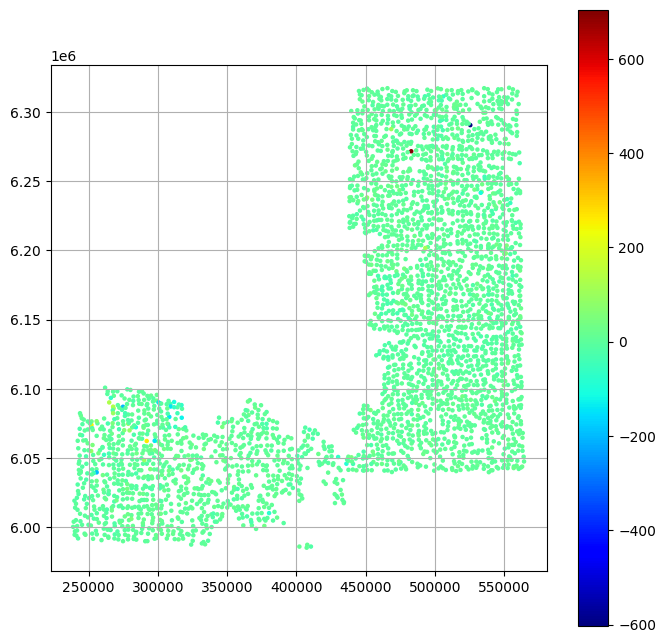

In [ ]:
gdf.plot(column = 'Zn_diff', s = 5, cmap = 'jet', legend = True, figsize = (8, 8))
plt.grid()

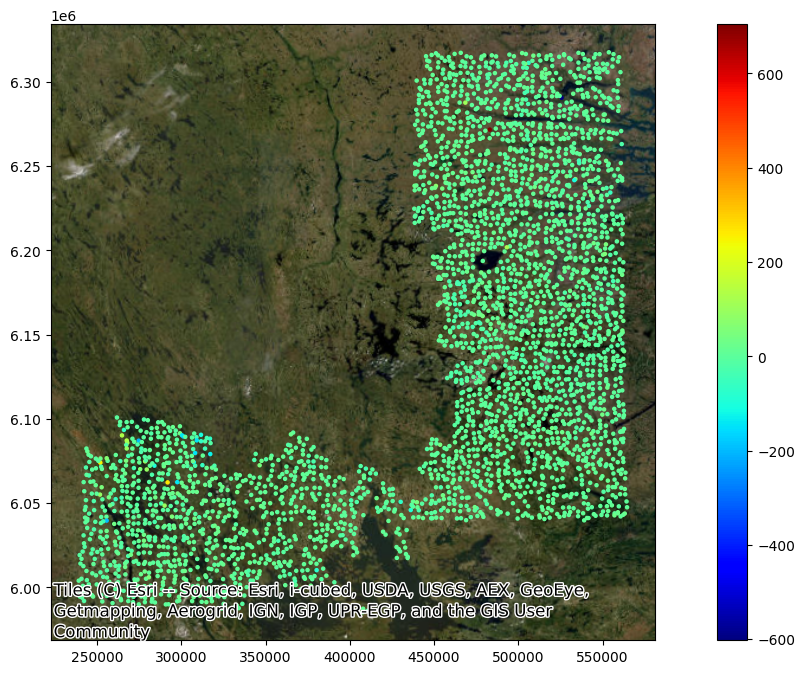

In [ ]:
# We can add a basemap to the plot now - you need internet connection to get the basemap from servers

fig, ax = plt.subplots(1, 1, figsize = (16,8))


gdf.plot(column = 'Zn_diff', s = 5, cmap = 'jet', legend = True, ax = ax)



ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery,
                crs=gdf.crs,
                attribution_size = 12,
               )
